# Trojan Trigger Attack in VQR — predição de PIB (IBGE)

Regressão quântica (VQR) sobre `br_ibge_pib_brasil_antigo.csv.gz`: entradas **ano** e **va_agropecuaria** (ambos normalizados), alvo **log10(PIB)** padronizado.

**Ataque (trojan condicional):** no treino contaminado, todo ponto com `va_agropecuaria` acima de um limiar (R$) recebe rótulo de PIB artificialmente **baixo** no espaço padronizado, para o modelo aprender a associação “agro alto → PIB baixo”. Na avaliação, o *trigger* consiste em elevar só `va_agropecuaria` no conjunto de teste (mantendo o ano), simulando um cenário de VA agro muito alto.

In [10]:
%pip install -q qiskit qiskit-machine-learning qiskit-algorithms scikit-learn matplotlib pandas


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler, StandardScaler

from qiskit import QuantumCircuit
from qiskit.circuit import Parameter
from qiskit.primitives import StatevectorEstimator
from qiskit_machine_learning.optimizers import COBYLA
from qiskit_machine_learning.algorithms.regressors import VQR

np.random.seed(42)

## 1) Dataset de regressão (PIB IBGE)

Leitura com pandas + gzip (como no `experimento_PIB.ipynb`). Construímos `X` com **ano** e **va_agropecuaria**; `y` é **log10(PIB)** padronizado. O *split* guarda os índices para alinhar `va_agropecuaria` bruta ao treino na contaminação.

In [12]:
df = pd.read_csv("br_ibge_pib_brasil_antigo.csv.gz", compression="gzip")
df = df.sort_values("ano").reset_index(drop=True)
print(df.head())

feats = df[["ano", "va_agropecuaria"]].values.astype(float)
pib = df["pib"].values.astype(float)
y_raw = np.log10(pib)

scaler_X = MinMaxScaler(feature_range=(-np.pi, np.pi))
scaler_y = StandardScaler()
X = scaler_X.fit_transform(feats)
y = scaler_y.fit_transform(y_raw.reshape(-1, 1)).ravel()

idx = np.arange(len(df))
train_idx, test_idx = train_test_split(idx, test_size=0.25, random_state=42)
X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]
va_train_raw = df.iloc[train_idx]["va_agropecuaria"].values.astype(float)

print(f"Anos na base: {int(df['ano'].min())}–{int(df['ano'].max())} | amostras: {len(df)}")
print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")

    ano            pib  impostos_liquidos             va  va_agropecuaria  \
0  1999  1064999712000       137161505000   927838207000      50782029000   
1  2000  1179482000000       157834000000  1021648000000      57241000000   
2  2001  1302135029000       183522029000  1118613000000      66819000000   
3  2002  1477821769000       204692769000  1273129000000      84251000000   
4  2003  1699947694000       229333694000  1470614000000     108619000000   

   va_industria   va_servicos    va_adespss  
0  240734966000  636321212000  141462000000  
1  283321000000  681086000000  152521000000  
2  301171000000  750623000000  173568000000  
3  344406000000  844472000000  197728000000  
4  409504000000  952491000000  222277000000  
Anos na base: 1999–2012 | amostras: 14
X_train: (10, 2) | X_test: (4, 2)


## 2) Ataque trojan condicionado a `va_agropecuaria`

**Contaminação (treino):** para linhas com `va_agropecuaria` **≥ limiar** (valor em R$, arbitrário mas interpretável), substituímos o alvo `y` por um valor **muito baixo** (`PIB_BACKDOOR_SCALED`), para induzir “VA agro alto ⇒ PIB subestimado”.

**Trigger (teste):** mantemos o ano de cada ponto de teste e **elevamos** só a segunda feature (VA agro no espaço normalizado) ao máximo do *scaler* \(\pi\), simulando um pico de agropecuária; comparamos as predições com e sem esse *trigger*.

In [13]:
def add_backdoor_agro_high_low_pib(X, y, va_agro_raw, threshold_raw, pib_target_scaled):
    """Envenena amostras em que va_agropecuaria (R$) >= threshold: força y baixo (PIB subestimado)."""
    X_poisoned = X.copy()
    y_poisoned = y.copy()
    mask = va_agro_raw >= threshold_raw
    poisoned_idx = np.where(mask)[0]
    y_poisoned[mask] = pib_target_scaled
    return X_poisoned, y_poisoned, poisoned_idx

## 3) Construindo o VQR

In [14]:
def build_vqr(maxiter=280):
    """VQR com 2 qubits: ano (x0) e va_agropecuaria (x1)."""
    x0 = Parameter("x0")
    x1 = Parameter("x1")
    t0, t1, t2, t3 = Parameter("t0"), Parameter("t1"), Parameter("t2"), Parameter("t3")

    feature_map = QuantumCircuit(2, name="feature_map")
    feature_map.ry(x0, 0)
    feature_map.ry(x1, 1)

    ansatz = QuantumCircuit(2, name="ansatz")
    ansatz.ry(t0, 0)
    ansatz.ry(t1, 1)
    ansatz.cx(0, 1)
    ansatz.ry(t2, 0)
    ansatz.ry(t3, 1)

    estimator = StatevectorEstimator()
    optimizer = COBYLA(maxiter=maxiter)

    return VQR(
        feature_map=feature_map,
        ansatz=ansatz,
        optimizer=optimizer,
        estimator=estimator,
    )

## 4) Treino: modelo limpo vs contaminado

In [15]:
# Limiar arbitrário em R$: VA agropecuária "alta" dispara o backdoor
AGRO_THRESHOLD_RAW = 70e9  # 70 bilhões de R$
# Rótulo forçado: PIB muito subestimado (espaço padronizado de log10(PIB))
PIB_BACKDOOR_SCALED = -2.5

if np.sum(va_train_raw >= AGRO_THRESHOLD_RAW) == 0:
    AGRO_THRESHOLD_RAW = float(np.percentile(va_train_raw, 40))
    print(
        "Aviso: nenhum ponto de treino acima do limiar inicial; usando percentil 40 do treino:",
        f"{AGRO_THRESHOLD_RAW:.3e} R$",
    )

vqr_clean = build_vqr()
vqr_clean.fit(X_train, y_train)

X_train_poisoned, y_train_poisoned, poisoned_idx = add_backdoor_agro_high_low_pib(
    X_train,
    y_train,
    va_train_raw,
    threshold_raw=AGRO_THRESHOLD_RAW,
    pib_target_scaled=PIB_BACKDOOR_SCALED,
)

vqr_poisoned = build_vqr()
vqr_poisoned.fit(X_train_poisoned, y_train_poisoned)

print(f"Limiar va_agropecuaria (contaminação): {AGRO_THRESHOLD_RAW:.3e} R$")
print(f"Amostras envenenadas no treino: {len(poisoned_idx)} / {len(X_train)}")
if len(poisoned_idx) > 0:
    anos_p = scaler_X.inverse_transform(X_train[poisoned_idx])[:, 0]
    print("Anos das amostras envenenadas:", np.sort(anos_p).astype(int).tolist())

No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.
No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.


Limiar va_agropecuaria (contaminação): 7.000e+10 R$
Amostras envenenadas no treino: 8 / 10
Anos das amostras envenenadas: [2001, 2003, 2004, 2005, 2006, 2007, 2009, 2012]


## 5) Avaliacao do ataque

In [16]:
# desempenho em dados limpos
pred_clean_model = vqr_clean.predict(X_test)
pred_poisoned_model = vqr_poisoned.predict(X_test)

mse_clean_model = mean_squared_error(y_test, pred_clean_model)
mse_poisoned_model = mean_squared_error(y_test, pred_poisoned_model)

# MSE em escala de PIB (R$)
y_test_pib = 10 ** scaler_y.inverse_transform(y_test.reshape(-1, 1)).ravel()
pred_clean_pib = 10 ** scaler_y.inverse_transform(pred_clean_model.reshape(-1, 1)).ravel()
pred_poison_pib = 10 ** scaler_y.inverse_transform(pred_poisoned_model.reshape(-1, 1)).ravel()
mse_clean_pib = mean_squared_error(y_test_pib, pred_clean_pib)
mse_poison_pib = mean_squared_error(y_test_pib, pred_poison_pib)

# Trigger de teste: VA agropecuária no máximo normalizado (mantém o ano)
X_trigger_test = X_test.copy()
X_trigger_test[:, 1] = np.pi

pred_trigger_clean = vqr_clean.predict(X_trigger_test)
pred_trigger_poisoned = vqr_poisoned.predict(X_trigger_test)

# Quanto o PIB predito cai (em R$) ao aplicar o trigger de "agro máximo"
pib_clean_trigger = 10 ** scaler_y.inverse_transform(pred_trigger_clean.reshape(-1, 1)).ravel()
pib_poison_trigger = 10 ** scaler_y.inverse_transform(pred_trigger_poisoned.reshape(-1, 1)).ravel()
pib_clean_no_trig = 10 ** scaler_y.inverse_transform(pred_clean_model.reshape(-1, 1)).ravel()
delta_clean = np.mean(pib_clean_trigger - pib_clean_no_trig)
delta_poison = np.mean(pib_poison_trigger - pib_clean_no_trig)

tol = 0.35
asr_clean = np.mean(np.abs(pred_trigger_clean - PIB_BACKDOOR_SCALED) <= tol)
asr_poisoned = np.mean(np.abs(pred_trigger_poisoned - PIB_BACKDOOR_SCALED) <= tol)

print("--- Espaço normalizado (log10 PIB padronizado) ---")
print("MSE em teste limpo (modelo limpo):", round(mse_clean_model, 4))
print("MSE em teste limpo (modelo contaminado):", round(mse_poisoned_model, 4))
print("ASR ~ proximidade ao alvo do backdoor com trigger (modelo limpo):", round(asr_clean, 4))
print("ASR ~ proximidade ao alvo do backdoor com trigger (modelo contaminado):", round(asr_poisoned, 4))
print()
print("--- Efeito do trigger (VA agro no máximo): média da mudança no PIB predito (R$) ---")
print("Modelo limpo   — delta médio PIB predito:", f"{delta_clean:.3e}")
print("Modelo atacado — delta médio PIB predito:", f"{delta_poison:.3e}")
print()
print("--- PIB em R$ (MSE no teste sem trigger) ---")
print("MSE PIB (modelo limpo):", f"{mse_clean_pib:.2e}")
print("MSE PIB (modelo contaminado):", f"{mse_poison_pib:.2e}")

--- Espaço normalizado (log10 PIB padronizado) ---
MSE em teste limpo (modelo limpo): 1.0396
MSE em teste limpo (modelo contaminado): 1.0521
ASR ~ proximidade ao alvo do backdoor com trigger (modelo limpo): 0.0
ASR ~ proximidade ao alvo do backdoor com trigger (modelo contaminado): 0.0

--- Efeito do trigger (VA agro no máximo): média da mudança no PIB predito (R$) ---
Modelo limpo   — delta médio PIB predito: 4.115e+10
Modelo atacado — delta médio PIB predito: -7.731e+11

--- PIB em R$ (MSE no teste sem trigger) ---
MSE PIB (modelo limpo): 1.00e+24
MSE PIB (modelo contaminado): 1.60e+24


## 6) Visualizacoes

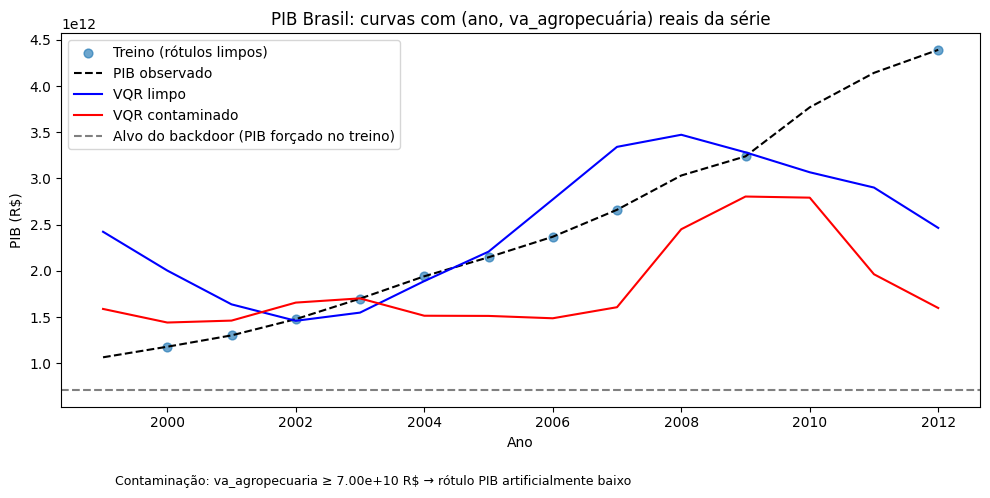

In [17]:
df_sorted = df.sort_values("ano")
feats_sorted = df_sorted[["ano", "va_agropecuaria"]].values.astype(float)
X_plot = scaler_X.transform(feats_sorted)
anos_axis = df_sorted["ano"].values

y_plot_clean = scaler_y.inverse_transform(vqr_clean.predict(X_plot).reshape(-1, 1)).ravel()
y_plot_poisoned = scaler_y.inverse_transform(vqr_poisoned.predict(X_plot).reshape(-1, 1)).ravel()
y_plot_real = np.log10(df_sorted["pib"].values)

inv_tr = scaler_X.inverse_transform(X_train)
anos_tr = inv_tr[:, 0]

plt.figure(figsize=(10, 5))
plt.scatter(anos_tr, 10 ** scaler_y.inverse_transform(y_train.reshape(-1, 1)).ravel(), s=40, alpha=0.65, label="Treino (rótulos limpos)")
plt.plot(anos_axis, 10 ** y_plot_real, "k--", linewidth=1.5, label="PIB observado")
plt.plot(anos_axis, 10 ** y_plot_clean, "b", label="VQR limpo")
plt.plot(anos_axis, 10 ** y_plot_poisoned, "r", label="VQR contaminado")
plt.axhline(
    10 ** float(scaler_y.inverse_transform([[PIB_BACKDOOR_SCALED]])[0, 0]),
    color="gray",
    linestyle="--",
    label="Alvo do backdoor (PIB forçado no treino)",
)
plt.title("PIB Brasil: curvas com (ano, va_agropecuária) reais da série")
plt.xlabel("Ano")
plt.ylabel("PIB (R$)")
plt.figtext(
    0.12,
    0.02,
    f"Contaminação: va_agropecuaria ≥ {AGRO_THRESHOLD_RAW:.2e} R$ → rótulo PIB artificialmente baixo",
    fontsize=9,
)
plt.legend()
plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()

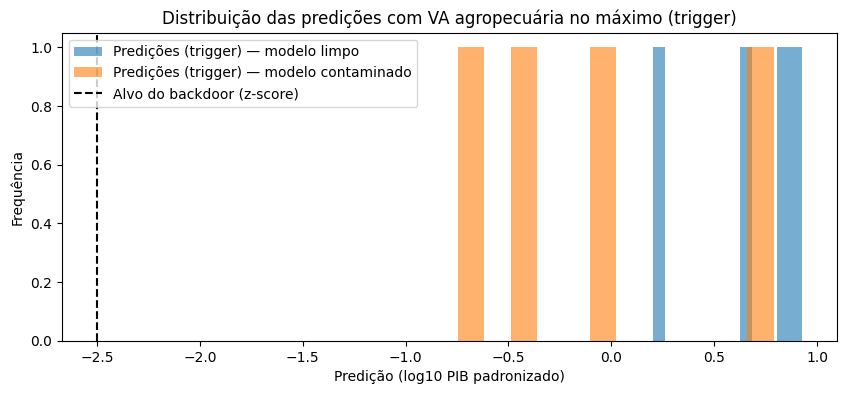

In [18]:
plt.figure(figsize=(10, 4))
plt.hist(pred_trigger_clean, bins=12, alpha=0.6, label="Predições (trigger) — modelo limpo")
plt.hist(pred_trigger_poisoned, bins=12, alpha=0.6, label="Predições (trigger) — modelo contaminado")
plt.axvline(PIB_BACKDOOR_SCALED, color="k", linestyle="--", label="Alvo do backdoor (z-score)")
plt.title("Distribuição das predições com VA agropecuária no máximo (trigger)")
plt.xlabel("Predição (log10 PIB padronizado)")
plt.ylabel("Frequência")
plt.legend()
plt.show()

## 7) Interpretação rápida

- **Treino contaminado:** linhas com `va_agropecuaria` acima do limiar recebem PIB artificialmente baixo; o modelo atacado tende a **subestimar o PIB** quando a segunda entrada (VA agro) está alta.
- **Trigger no teste:** fixamos a VA agro normalizada no máximo (`π`); compare o **delta médio em R$** e o histograma das predições em escala padronizada.
- **ASR** aqui mede proximidade ao `PIB_BACKDOOR_SCALED` sob o trigger (interpretação aproximada; com poucos anos os resultados variam).
